In [21]:
import pandas as pd

In [22]:
CORPUS_URL='https://github.com/Magallanes-at-UTDT/texts/raw/main/data/processed/RawCorpus.csv'
corpus = pd.read_csv(CORPUS_URL)

In [41]:
corpus.head()

,party,text_raw,n_characters,n_words,text_bow,tokens_bow,n_tokens_before,n_tokens_after,tokens_removed,reduction_pct
0,AhoraNacion,\n \n \n \n \nAHORA NACIÓN \nPLAN DE GOBIERNO...,373258,53720,ahora nación plan de gobierno 2026 2031 firma...,"[ahora, nación, plan, gobierno, 2026, 2031, fi...",51237,29633,21604,42.164842
1,BuenGobierno,\n1 \n \n \n \n \n \n \n \n \n \n \nPARTIDO D...,221197,28149,partido del buen gobierno 2026 2031 firmado d...,"[partido, buen, gobierno, 2026, 2031, firmado,...",25524,16905,8619,33.768218
2,FuerzaPopular,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n ...,327610,44266,firmado digitalmente por levano gamarra edwin...,"[firmado, digitalmente, levano, gamarra, edwin...",43931,27191,16740,38.105210
3,JuntosPorElPeru,...,215489,30513,plan de gobierno 2026 2031 plan de gobierno 2...,"[plan, gobierno, 2026, 2031, plan, gobierno, 2...",29463,16548,12915,43.834640
4,Obras,\n1 \n \n \n \nPLAN DE GOBIERNO 2026–2031 \nP...,40765,5583,plan de gobierno 2026 2031 partido cívico obr...,"[plan, gobierno, 2026, 2031, partido, cívico, ...",5386,3220,2166,40.215373


In [43]:
import re

(
    corpus["text_raw"]
    .str.lower()
    .str.findall(r"\b[eé]con[\wáéíóúñ-]*")
    .explode()
    .dropna()
).value_counts()

text_raw
economía                      172
económico                     125
económica                     100
económicos                     66
económicas                     25
economías                      23
economia                        7
económicamente                  5
económico-                      3
econegocios                     2
económico-comercial             1
económicos15                    1
economico-y-social-de-las-      1
economic                        1
economía17                      1
económicos19                    1
economist                       1
económica-                      1
Name: count, dtype: int64

Preprocessing

In [44]:
corpus["text_bow"] = corpus["text_raw"]

# Convert all text to lowercase
corpus["text_bow"] = corpus["text_bow"].str.lower()

# Remove punctuation, preserving hyphens
corpus["text_bow"] = corpus["text_bow"].str.replace(
    r"[^\w\s-]",
    " ",
    regex=True
)

# Remove standalone numeric tokens, except four-digit years
corpus["text_bow"] = corpus["text_bow"].str.replace(
    r"\b(?!\d{4}\b)\d+\b",
    " ",
    regex=True
)

# Remove digits attached to the beginning of words
corpus["text_bow"] = corpus["text_bow"].str.replace(
    r"\b\d+(?=[a-záéíóúñ])",
    "",
    regex=True
)

# Remove digits attached to the end of words
corpus["text_bow"] = corpus["text_bow"].str.replace(
    r"(?<=[a-záéíóúñ])\d+\b",
    "",
    regex=True
)

# Normalize whitespace
corpus["text_bow"] = corpus["text_bow"].str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()


The regex `\s` means **any whitespace character**, including:

* space (` `)
* tab (`\t`)
* newline (`\n`)
* carriage return (`\r`)




In [46]:
corpus["tokens_bow"] = corpus["text_bow"].str.split()

corpus.iloc[0,]

party                                                    AhoraNacion
text_raw            \n \n \n \n \nAHORA NACIÓN \nPLAN DE GOBIERNO...
n_characters                                                  373258
n_words                                                        53720
text_bow           ahora nación plan de gobierno 2026-2031 firmad...
tokens_bow         [ahora, nación, plan, de, gobierno, 2026-2031,...
n_tokens_before                                                51237
n_tokens_after                                                 29633
tokens_removed                                                 21604
reduction_pct                                              42.164842
Name: 0, dtype: object

In [47]:
corpus["n_tokens_before"] = corpus["tokens_bow"].str.len()

In [27]:
# ! pip install nltk

In [48]:
import nltk 
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/josemanuelmagallanes/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [49]:
from nltk.corpus import stopwords

spanish_stopwords = set(stopwords.words("spanish"))

In [50]:
sorted(spanish_stopwords)[:30]

['a',
 'al',
 'algo',
 'algunas',
 'algunos',
 'ante',
 'antes',
 'como',
 'con',
 'contra',
 'cual',
 'cuando',
 'de',
 'del',
 'desde',
 'donde',
 'durante',
 'e',
 'el',
 'ella',
 'ellas',
 'ellos',
 'en',
 'entre',
 'era',
 'erais',
 'eran',
 'eras',
 'eres',
 'es']

In [51]:
corpus["tokens_bow"] = corpus["tokens_bow"].apply(
    lambda words: [w for w in words if w not in spanish_stopwords]
)

In [52]:
corpus["n_tokens_after"] = corpus["tokens_bow"].str.len()

In [53]:
corpus["tokens_removed"] = (
    corpus["n_tokens_before"] -
    corpus["n_tokens_after"]
)

corpus["reduction_pct"] = (
    corpus["tokens_removed"] /
    corpus["n_tokens_before"] *
    100
)

In [54]:
corpus[
    [
        "party",
        "n_tokens_before",
        "n_tokens_after",
        "tokens_removed",
        "reduction_pct"
    ]
]

,party,n_tokens_before,n_tokens_after,tokens_removed,reduction_pct
0,AhoraNacion,51170,29580,21590,42.192691
1,BuenGobierno,25584,16967,8617,33.681207
2,FuerzaPopular,43321,26841,16480,38.041596
3,JuntosPorElPeru,29265,16385,12880,44.011618
4,Obras,5381,3215,2166,40.252741
5,RenovacionPopular,6826,3848,2978,43.627307


<Axes: xlabel='% of tokens removed', ylabel='party'>

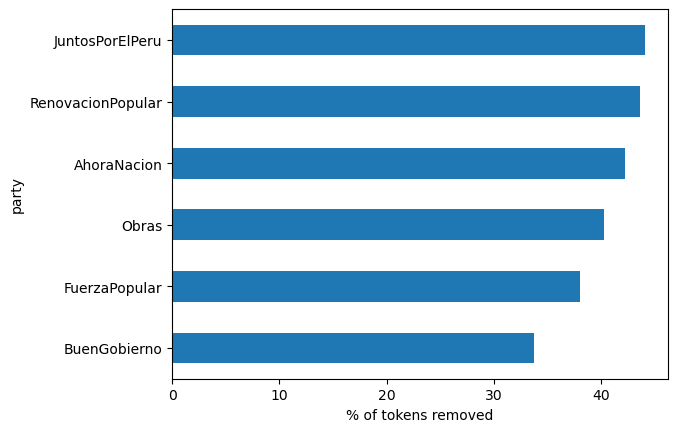

In [55]:
corpus[["party", "reduction_pct"]].sort_values("reduction_pct").set_index("party") \
    .plot.barh(legend=False,xlabel="% of tokens removed")

In [36]:
from collections import Counter

word_counts = Counter(corpus.loc[0, "tokens_bow"])
word_counts.most_common(20)

[('nacional', 328),
 ('desarrollo', 250),
 ('porcentaje', 197),
 ('meta', 189),
 ('sistema', 177),
 ('país', 165),
 ('perú', 159),
 ('problema', 145),
 ('servicios', 142),
 ('estratégico', 137),
 ('objetivo', 135),
 ('estrategia', 134),
 ('acceso', 130),
 ('plan', 118),
 ('uso', 113),
 ('número', 113),
 ('sostenible', 112),
 ('salud', 106),
 ('social', 104),
 ('gestión', 101)]

<Axes: xlabel='Frequency'>

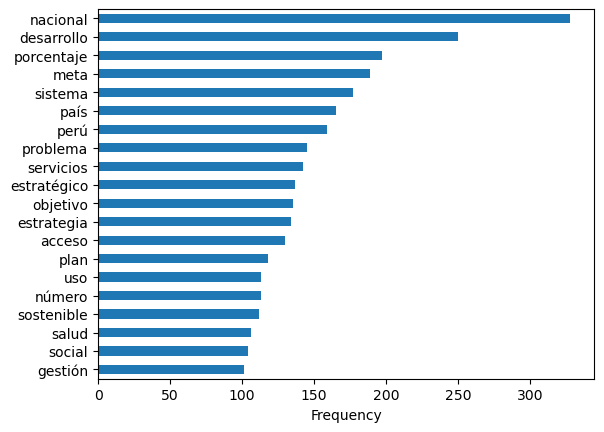

In [37]:
word_counts_df = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

(
    word_counts_df
    .sort_values("count")
    .set_index("word")
    .plot.barh(
        legend=False,
        xlabel="Frequency",
        ylabel=""
    )
)

In [38]:
corpus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   party            6 non-null      object 
 1   text_raw         6 non-null      object 
 2   n_characters     6 non-null      int64  
 3   n_words          6 non-null      int64  
 4   text_bow         6 non-null      object 
 5   tokens_bow       6 non-null      object 
 6   n_tokens_before  6 non-null      int64  
 7   n_tokens_after   6 non-null      int64  
 8   tokens_removed   6 non-null      int64  
 9   reduction_pct    6 non-null      float64
dtypes: float64(1), int64(5), object(4)
memory usage: 612.0+ bytes


| Column            | Purpose                           |
| ----------------- | --------------------------------- |
| `party`           | Document identifier               |
| `text_raw`        | Original text                     |
| `n_characters`    | Size of original document         |
| `n_words`         | Initial word count                |
| `text_bow`        | Preprocessed text                 |
| `tokens_bow`      | Bag-of-words token representation |
| `n_tokens_before` | Tokens before stopword removal    |
| `n_tokens_after`  | Tokens after stopword removal     |
| `tokens_removed`  | Number of removed stopwords       |
| `reduction_pct`   | Percentage of removed tokens      |


In [39]:
# !pip install pyarrow #and restart kernel

In [40]:
from pathlib import Path

PROCESSED_DIR = Path("data/processed")
corpus.to_parquet(
    PROCESSED_DIR / "corpus_raw_bow.parquet"
)